In [2]:
import pandas as pd
import numpy as np
import os

Catalogo de SOFIPOS

In [3]:
dir_sofipos = r'C:\Users\lrebollar.e\OneDrive - fincomun.com.mx\Documentos\GitHub\Dashboard Sofipos - Fincomún\cat_instituciones_27.csv'
df_sofipos = pd.read_csv(dir_sofipos, encoding='latin1')
df_sofipos = df_sofipos[['entidad', 'nombre_entidad']]

Nomenclatura de los datos

In [4]:
dir_dicc = r'C:\Users\lrebollar.e\OneDrive - fincomun.com.mx\Documentos\GitHub\Dashboard Sofipos - Fincomún\cat_conceptos_27.csv'
df_dicc = pd.read_csv(dir_dicc, encoding='latin1')

df_dicc_s = df_dicc[['idconcepto', 'descripcion', 'nivel']]

Base global SOFIPOs

In [5]:
dir_df = r'C:\Users\lrebollar.e\OneDrive - fincomun.com.mx\Documentos\GitHub\Dashboard Sofipos - Fincomún\sh_datos_csv_27\sh_datos_27.csv'
df = pd.read_csv(dir_df)

# Se agregan identificadores de variables
df = pd.merge(left=df, right=df_dicc_s, on ='idconcepto', how='left')

# Se agregan nombres de las SOFIPOS
df = pd.merge(left=df, right=df_sofipos, on ='entidad', how='left')

df = df[['nivel',
         'idconcepto',
         'descripcion',
         'entidad',
         'nombre_entidad',
         'periodo',
         'valor'
         ]]

df['periodo'] = pd.to_datetime(df['periodo'].astype(str), format='%Y%m').dt.to_period('M')

In [17]:
df_act = df[((df['periodo'] == max(df['periodo'])) & (df['descripcion'] == 'Activo'))]
df_act = df_act[df_act['nombre_entidad'] != 'Total SOFIPOS']

df_act = df_act.sort_values(by='valor')

In [18]:
df_act

,nivel,idconcepto,descripcion,entidad,nombre_entidad,periodo,valor
629250,1,27100001,Activo,27049,Porvenir,2026-06,5.734184e+06
518107,1,27100001,Activo,27040,Impulso,2026-06,2.895322e+07
644421,1,27100001,Activo,27051,Grensa,2026-06,3.571908e+07
303131,1,27100001,Activo,27025,Finsocial,2026-06,7.902397e+07
537899,1,27100001,Activo,27042,Paso Seguro,2026-06,1.013260e+08
554975,1,27100001,Activo,27044,Súmate,2026-06,1.666427e+08
486953,1,27100001,Activo,27037,Financiera Más,2026-06,1.966914e+08
194868,1,27100001,Activo,27015,Operaciones de tu Lado,2026-06,3.395820e+08
260434,1,27100001,Activo,27020,Multiplica,2026-06,3.451539e+08
160716,1,27100001,Activo,27013,Credicapital,2026-06,3.586466e+08


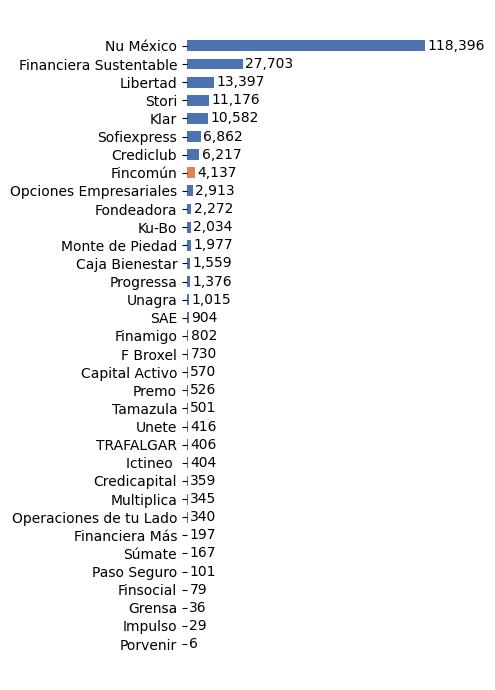

In [28]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

categorias = df_act['nombre_entidad']
valores = round(df_act['valor']/1000000, 2)

# Color especial para Fincomún, color base para las demás
color_base = '#4C72B0'
color_destacado = '#DD8452'
colores = [color_destacado if cat == 'Fincomún' else color_base for cat in categorias]

fig, ax = plt.subplots(figsize=(5, 7))
ax.barh(categorias, valores, color=colores, height=0.6)

# Quitar el recuadro (spines)
for spine in ax.spines.values():
    spine.set_visible(False)

# Ocultar el eje X por completo
ax.xaxis.set_visible(False)

ax.set_xlabel('Activo en MDP')

# Formato con comas en el eje X
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Formato con comas en las etiquetas al final de cada barra
for i, v in enumerate(valores):
    ax.text(v + max(valores)*0.01, i, f'{v:,.0f}', va='center')

plt.tight_layout()
plt.show()

In [29]:
sofipos_nam = ['Total SOFIPOS', # Sector SOFIPOS
               'Fincomún',      
               'Nu México',     # SOFIPO más grande
               'Crediclub',     # SOFIPO más grande que Fincomún
               'Opciones Empresariales' # SOFIPO más chica que Fincomún
               ]

In [51]:
df_cartera = pd.DataFrame(
    columns= ['periodo',
 'Cartera de crédito',
 'Créditos comerciales',
 'Créditos consumo',
 'Créditos vivienda',
 'Cartera de crédito_i_b100',
 'Cartera de crédito_pct_YoY',
 'Créditos comerciales_i_b100',
 'Créditos comerciales_pct_YoY',
 'Créditos consumo_i_b100',
 'Créditos consumo_pct_YoY',
 'Créditos vivienda_i_b100',
 'Créditos vivienda_pct_YoY',
 'Créditos comerciales_w',
 'Créditos consumo_w',
 'Créditos vivienda_w',
 'sofipo']
    )

#### Cartera de crédito

In [52]:
for sofipo in sofipos_nam: 

    df_sofipo = df[df['nombre_entidad'] == sofipo]

    var_cartera = [
        27100008, # Cartera
        27100009, # C. Comerciales
        27100010, # C. Consumo
        27100011  # C. Vivienda
    ]

    df_sofipo_cartera = df_sofipo[df_sofipo['idconcepto'].isin(var_cartera)]

    df_sofipo_cartera_pivot = df_sofipo_cartera.pivot(
        index='periodo',
        columns='descripcion',
        values='valor'
    ).reset_index()

    # Transformaciones internas
    vars = df_sofipo_cartera_pivot.columns.to_list()[1:]

    # Indicador Base 07-2022 == 100
    for var in vars:

        base = df_sofipo_cartera_pivot[df_sofipo_cartera_pivot['periodo'] == '2022-07'][var].iat[0]
        df_sofipo_cartera_pivot[f'{var}_i_b100'] = round((df_sofipo_cartera_pivot[var]/base)*100, 2)
        df_sofipo_cartera_pivot[f'{var}_pct_YoY'] = round(df_sofipo_cartera_pivot[var].pct_change(periods=12)*100, 2)

    # Pesos
    vars = df_sofipo_cartera_pivot.columns.to_list()[2:5]

    for var in vars:

        df_sofipo_cartera_pivot[f'{var}_w'] = round((df_sofipo_cartera_pivot[var]/df_sofipo_cartera_pivot['Cartera de crédito'])*100, 2)

    df_sofipo_cartera_pivot['sofipo'] = sofipo

    df_cartera = pd.concat([df_cartera, df_sofipo_cartera_pivot], ignore_index=True)

## Cuentas de Activo
#### Estimación preventiva para riesgos crediticios

In [48]:
df_riesgo = pd.DataFrame(
    columns= ['periodo',
 'Créditos comerciales',
 'Créditos consumo',
 'Créditos vivienda',
 'Estimaciones preventivas para riesgos crediticios adicional',
 'Estimación preventiva para riesgos crediticios',
 'Créditos comerciales_i_b100',
 'Créditos comerciales_pct_YoY',
 'Créditos consumo_i_b100',
 'Créditos consumo_pct_YoY',
 'Créditos vivienda_i_b100',
 'Créditos vivienda_pct_YoY',
 'Estimaciones preventivas para riesgos crediticios adicional_i_b100',
 'Estimaciones preventivas para riesgos crediticios adicional_pct_YoY',
 'Estimación preventiva para riesgos crediticios_i_b100',
 'Estimación preventiva para riesgos crediticios_pct_YoY',
 'Créditos comerciales_w',
 'Créditos consumo_w',
 'Créditos vivienda_w',
 'Estimaciones preventivas para riesgos crediticios adicional_w',
 'sofipo']) 

In [49]:
for sofipo in sofipos_nam:

    df_sofipo = df[df['nombre_entidad'] == sofipo]

    var_riesgo = [
    27100012, # Cartera
    27100013, # C. Comerciales
    27100014, # C. Consumo
    27100015,  # C. Vivienda
    27100148
    ]

    df_sofipo_riesgo = df_sofipo[df_sofipo['idconcepto'].isin(var_riesgo)]

    df_sofipo_riesgo_pivot = df_sofipo_riesgo.pivot(
    index='periodo',
    columns='descripcion',
    values='valor'
    ).reset_index()

    # Transformaciones internas
    vars = df_sofipo_riesgo_pivot.columns.to_list()[1:]

    # Indicador Base 07-2022 == 100
    for var in vars:

        base = df_sofipo_riesgo_pivot[df_sofipo_riesgo_pivot['periodo'] == '2022-07'][var].iat[0]
        df_sofipo_riesgo_pivot[f'{var}_i_b100'] = round((df_sofipo_riesgo_pivot[var]/base)*100, 2)
        df_sofipo_riesgo_pivot[f'{var}_pct_YoY'] = round(df_sofipo_riesgo_pivot[var].pct_change(periods=12)*100, 2)

    # Pesos
    vars = df_sofipo_riesgo_pivot.columns.to_list()[1:5]

    for var in vars:

        df_sofipo_riesgo_pivot[f'{var}_w'] = round((df_sofipo_riesgo_pivot[var]/df_sofipo_riesgo_pivot['Estimación preventiva para riesgos crediticios'])*100, 2)

    df_sofipo_riesgo_pivot['sofipo'] = sofipo

    df_riesgo = pd.concat([df_riesgo, df_sofipo_riesgo_pivot], ignore_index=True)

#### Cartera de crédito con riesgo de crédito (E1 + E2)

In [63]:
df_riesgo_E1E2 = pd.DataFrame(columns= ['periodo',
 'Cartera de crédito con riesgo de crédito (E1 + E2)',
 'Créditos comerciales (E1 + E2)',
 'Créditos consumo (E1 + E2)',
 'Créditos vivienda (E1 + E2)',
 'Cartera de crédito con riesgo de crédito (E1 + E2)_i_b100',
 'Cartera de crédito con riesgo de crédito (E1 + E2)_pct_YoY',
 'Créditos comerciales (E1 + E2)_i_b100',
 'Créditos comerciales (E1 + E2)_pct_YoY',
 'Créditos consumo (E1 + E2)_i_b100',
 'Créditos consumo (E1 + E2)_pct_YoY',
 'Créditos vivienda (E1 + E2)_i_b100',
 'Créditos vivienda (E1 + E2)_pct_YoY',
 'Créditos comerciales (E1 + E2)_w',
 'Créditos consumo (E1 + E2)_w',
 'Créditos vivienda (E1 + E2)_w',
 'sofipo']
 )

In [64]:
for sofipo in sofipos_nam:

    df_sofipo = df[df['nombre_entidad'] == sofipo]

    var_riesgo_E1E2 = [
        27100037, # Cartera
        27100038, # C. Comerciales
        27100039, # C. Consumo
        27100040  # C. Vivienda
    ]

    df_sofipo_riesgo_E1E2 = df_sofipo[df_sofipo['idconcepto'].isin(var_riesgo_E1E2)]

    df_sofipo_riesgo_E1E2_pivot = df_sofipo_riesgo_E1E2.pivot(
        index='periodo',
        columns='descripcion',
        values='valor'
    ).reset_index()

    # Transformaciones internas
    vars = df_sofipo_riesgo_E1E2_pivot.columns.to_list()[1:]

    # Indicador Base 07-2022 == 100
    for var in vars:

        base = df_sofipo_riesgo_E1E2_pivot[df_sofipo_riesgo_E1E2_pivot['periodo'] == '2022-07'][var].iat[0]
        df_sofipo_riesgo_E1E2_pivot[f'{var}_i_b100'] = round((df_sofipo_riesgo_E1E2_pivot[var]/base)*100, 2)
        df_sofipo_riesgo_E1E2_pivot[f'{var}_pct_YoY'] = round(df_sofipo_riesgo_E1E2_pivot[var].pct_change(periods=12)*100, 2)

    # Pesos
    vars = df_sofipo_riesgo_E1E2_pivot.columns.to_list()[2:5]

    for var in vars:

        df_sofipo_riesgo_E1E2_pivot[f'{var}_w'] = round((df_sofipo_riesgo_E1E2_pivot[var]/df_sofipo_riesgo_E1E2_pivot['Cartera de crédito con riesgo de crédito (E1 + E2)'])*100, 2)

    df_sofipo_riesgo_E1E2_pivot['sofipo'] = sofipo

    df_riesgo_E1E2 = pd.concat([df_riesgo_E1E2, df_sofipo_riesgo_E1E2_pivot], ignore_index=True)


#### Cartera de crédito con riesgo de crédito etapa 3

In [73]:
df_riesgo_E3 = pd.DataFrame(columns=['periodo',
 'Cartera de crédito con riesgo de crédito etapa 3',
 'Créditos comerciales',
 'Créditos consumo',
 'Créditos vivienda',
 'Cartera de crédito con riesgo de crédito etapa 3_i_b100',
 'Cartera de crédito con riesgo de crédito etapa 3_pct_YoY',
 'Créditos comerciales_i_b100',
 'Créditos comerciales_pct_YoY',
 'Créditos consumo_i_b100',
 'Créditos consumo_pct_YoY',
 'Créditos vivienda_i_b100',
 'Créditos vivienda_pct_YoY',
 'Créditos comerciales_w',
 'Créditos consumo_w',
 'Créditos vivienda_w',
 'sofipo'])

In [74]:
for sofipo in sofipos_nam:

    df_sofipo = df[df['nombre_entidad'] == sofipo]

    var_riesgo_E3 = [
        27100004, # Cartera
        27100005, # C. Comerciales
        27100006, # C. Consumo
        27100007  # C. Vivienda
    ]

    df_sofipo_riesgo_E3 = df_sofipo[df_sofipo['idconcepto'].isin(var_riesgo_E3)]

    df_sofipo_riesgo_E3_pivot = df_sofipo_riesgo_E3.pivot(
        index='periodo',
        columns='descripcion',
        values='valor'
    ).reset_index()

    # Transformaciones internas
    vars = df_sofipo_riesgo_E3_pivot.columns.to_list()[1:]

    # Indicador Base 07-2022 == 100
    for var in vars:

        base = df_sofipo_riesgo_E3_pivot[df_sofipo_riesgo_E3_pivot['periodo'] == '2022-07'][var].iat[0]
        df_sofipo_riesgo_E3_pivot[f'{var}_i_b100'] = round((df_sofipo_riesgo_E3_pivot[var]/base)*100, 2)
        df_sofipo_riesgo_E3_pivot[f'{var}_pct_YoY'] = round(df_sofipo_riesgo_E3_pivot[var].pct_change(periods=12)*100, 2)

    # Pesos
    vars = df_sofipo_riesgo_E3_pivot.columns.to_list()[2:5]

    for var in vars:

        df_sofipo_riesgo_E3_pivot[f'{var}_w'] = round((df_sofipo_riesgo_E3_pivot[var]/df_sofipo_riesgo_E3_pivot['Cartera de crédito con riesgo de crédito etapa 3'])*100, 2)

    df_sofipo_riesgo_E3_pivot['sofipo'] = sofipo

    df_riesgo_E3 = pd.concat([df_riesgo_E3, df_sofipo_riesgo_E3_pivot], ignore_index=True)

## Cuentas de Pasivo
#### Captación Tradicional

In [82]:
df_captacion = pd.DataFrame(columns= ['periodo',
 'Captación tradicional',
 'Cuenta global de captación sin movimientos',
 'Depósitos a plazo',
 'Depósitos de exigibilidad inmediata',
 'Títulos de crédito emitidos',
 'Captación tradicional_i_b100',
 'Captación tradicional_pct_YoY',
 'Cuenta global de captación sin movimientos_i_b100',
 'Cuenta global de captación sin movimientos_pct_YoY',
 'Depósitos a plazo_i_b100',
 'Depósitos a plazo_pct_YoY',
 'Depósitos de exigibilidad inmediata_i_b100',
 'Depósitos de exigibilidad inmediata_pct_YoY',
 'Títulos de crédito emitidos_i_b100',
 'Títulos de crédito emitidos_pct_YoY',
 'Cuenta global de captación sin movimientos_w',
 'Depósitos a plazo_w',
 'Depósitos de exigibilidad inmediata_w',
 'Títulos de crédito emitidos_w',
 'sofipo'])

In [83]:
for sofipo in sofipos_nam:

    df_sofipo = df[df['nombre_entidad'] == sofipo]

    var_captacion = [
        27100044, # Captación tradicional NVL 1
        27100028, # Depósitos de exigibilidad inmediata
        27100029, # Depósitos a plazo
        27100158, # Títulos de crédito emitidos
        27100083  # Cuenta global de captación sin movimientos
    ]

    df_sofipo_captacion = df_sofipo[df_sofipo['idconcepto'].isin(var_captacion)]

    df_sofipo_captacion_pivot = df_sofipo_captacion.pivot(
        index='periodo',
        columns='descripcion',
        values='valor'
    ).reset_index()

    # Transformaciones internas
    vars = df_sofipo_captacion_pivot.columns.to_list()[1:]

    # Indicador Base 07-2022 == 100
    for var in vars:

        base = df_sofipo_captacion_pivot[df_sofipo_captacion_pivot['periodo'] == '2022-07'][var].iat[0]
        df_sofipo_captacion_pivot[f'{var}_i_b100'] = round((df_sofipo_captacion_pivot[var]/base)*100, 2)
        df_sofipo_captacion_pivot[f'{var}_pct_YoY'] = round(df_sofipo_captacion_pivot[var].pct_change(periods=12)*100, 2)

    # Pesos
    vars = df_sofipo_captacion_pivot.columns.to_list()[2:6]

    for var in vars:

        df_sofipo_captacion_pivot[f'{var}_w'] = round((df_sofipo_captacion_pivot[var]/df_sofipo_captacion_pivot['Captación tradicional'])*100, 2)

    df_sofipo_captacion_pivot['sofipo'] = sofipo

    df_captacion = pd.concat([df_captacion, df_sofipo_captacion_pivot], ignore_index=True)


#### Préstamos bancarios y de otros organismos

In [88]:
df_prestamosb = pd.DataFrame(columns=['periodo',
 'De corto plazo',
 'De largo plazo',
 'Préstamos bancarios y de otros organismos',
 'De corto plazo_i_b100',
 'De corto plazo_pct_YoY',
 'De largo plazo_i_b100',
 'De largo plazo_pct_YoY',
 'Préstamos bancarios y de otros organismos_i_b100',
 'Préstamos bancarios y de otros organismos_pct_YoY',
 'De corto plazo_w',
 'De largo plazo_w',
 'sofipo'])

In [89]:
for sofipo in sofipos_nam:

    df_sofipo = df[df['nombre_entidad'] == sofipo]

    var_prestamosb = [
        27100030, # Préstamos bancarios y de otros organismos NVL 1
        27100159, # De corto plazo
        27100160, # De largo plazo
    ]

    df_sofipo_prestamosb = df_sofipo[df_sofipo['idconcepto'].isin(var_prestamosb)]

    df_sofipo_prestamosb_pivot = df_sofipo_prestamosb.pivot(
        index='periodo',
        columns='descripcion',
        values='valor'
    ).reset_index()

    # Transformaciones internas
    vars = df_sofipo_prestamosb_pivot.columns.to_list()[1:]

    # Indicador Base 07-2022 == 100
    for var in vars:

        base = df_sofipo_prestamosb_pivot[df_sofipo_prestamosb_pivot['periodo'] == '2022-07'][var].iat[0]
        df_sofipo_prestamosb_pivot[f'{var}_i_b100'] = round((df_sofipo_prestamosb_pivot[var]/base)*100, 2)
        df_sofipo_prestamosb_pivot[f'{var}_pct_YoY'] = round(df_sofipo_prestamosb_pivot[var].pct_change(periods=12)*100, 2)

    # Pesos
    vars = df_sofipo_prestamosb_pivot.columns.to_list()[1:3]

    for var in vars:

        df_sofipo_prestamosb_pivot[f'{var}_w'] = round((df_sofipo_prestamosb_pivot[var]/df_sofipo_prestamosb_pivot['Préstamos bancarios y de otros organismos'])*100, 2)

    df_sofipo_prestamosb_pivot['sofipo'] = sofipo

    df_prestamosb = pd.concat([df_prestamosb, df_sofipo_prestamosb_pivot], ignore_index=True)

## Cuentas de Capital
#### Capital Contable

In [94]:
df_CC = pd.DataFrame(columns=['periodo',
 'Capital contable',
 'Capital contribuido',
 'Capital ganado',
 'Capital contable_i_b100',
 'Capital contable_pct_YoY',
 'Capital contribuido_i_b100',
 'Capital contribuido_pct_YoY',
 'Capital ganado_i_b100',
 'Capital ganado_pct_YoY',
 'Capital contribuido_w',
 'Capital ganado_w',
 'sofipo'])

In [95]:
for sofipo in sofipos_nam:

    df_sofipo = df[df['nombre_entidad'] == sofipo]

    var_CC = [
        27100002, # Capital contable NVL 1
        27100084, # Capital contribuido
        27100086, # Capital ganado
    ]

    df_sofipo_CC = df_sofipo[df_sofipo['idconcepto'].isin(var_CC)]

    df_sofipo_CC_pivot = df_sofipo_CC.pivot(
        index='periodo',
        columns='descripcion',
        values='valor'
    ).reset_index()

    # Transformaciones internas
    vars = df_sofipo_CC_pivot.columns.to_list()[1:]

    # Indicador Base 07-2022 == 100
    for var in vars:

        base = df_sofipo_CC_pivot[df_sofipo_CC_pivot['periodo'] == '2022-07'][var].iat[0]
        df_sofipo_CC_pivot[f'{var}_i_b100'] = round((df_sofipo_CC_pivot[var]/base)*100, 2)
        df_sofipo_CC_pivot[f'{var}_pct_YoY'] = round(df_sofipo_CC_pivot[var].pct_change(periods=12)*100, 2)

    # Pesos
    vars = df_sofipo_CC_pivot.columns.to_list()[2:4]

    for var in vars:

        df_sofipo_CC_pivot[f'{var}_w'] = round((df_sofipo_CC_pivot[var]/df_sofipo_CC_pivot['Capital contable'])*100, 2)

    df_sofipo_CC_pivot['sofipo'] = sofipo

    df_CC = pd.concat([df_CC, df_sofipo_CC_pivot], ignore_index=True)

##### Capital Ganado

In [102]:
df_CG = pd.DataFrame(columns=['periodo',
 'Capital ganado',
 'Incremento por actualización de reservas de capital ',
 'Otros resultados integrales',
 'Reservas de capital',
 'Resultados acumulados',
 'Capital ganado_i_b100',
 'Capital ganado_pct_YoY',
 'Incremento por actualización de reservas de capital _i_b100',
 'Incremento por actualización de reservas de capital _pct_YoY',
 'Otros resultados integrales_i_b100',
 'Otros resultados integrales_pct_YoY',
 'Reservas de capital_i_b100',
 'Reservas de capital_pct_YoY',
 'Resultados acumulados_i_b100',
 'Resultados acumulados_pct_YoY',
 'Incremento por actualización de reservas de capital _w',
 'Otros resultados integrales_w',
 'Reservas de capital_w',
 'Resultados acumulados_w',
 'sofipo'])

In [103]:
for sofipo in sofipos_nam:

    df_sofipo = df[df['nombre_entidad'] == sofipo]

    var_CG = [
        27100086, # Capital ganado NVL 2
        27100165, # Reservas de capital
        27100166, # Incremento por actualización de reservas de capital 
        27100211, # Resultados acumulados
        27100212  # Otros resultados integrales
    ]

    df_sofipo_CG = df_sofipo[df_sofipo['idconcepto'].isin(var_CG)]

    df_sofipo_CG_pivot = df_sofipo_CG.pivot(
        index='periodo',
        columns='descripcion',
        values='valor'
    ).reset_index()

    # Transformaciones internas
    vars = df_sofipo_CG_pivot.columns.to_list()[1:]

    # Indicador Base 07-2022 == 100
    for var in vars:

        base = df_sofipo_CG_pivot[df_sofipo_CG_pivot['periodo'] == '2022-07'][var].iat[0]
        df_sofipo_CG_pivot[f'{var}_i_b100'] = round((df_sofipo_CG_pivot[var]/base)*100, 2)
        df_sofipo_CG_pivot[f'{var}_pct_YoY'] = round(df_sofipo_CG_pivot[var].pct_change(periods=12)*100, 2)

    # Pesos
    vars = df_sofipo_CG_pivot.columns.to_list()[2:6]

    for var in vars:

        df_sofipo_CG_pivot[f'{var}_w'] = round((df_sofipo_CG_pivot[var]/df_sofipo_CG_pivot['Capital ganado'])*100, 2)

    df_sofipo_CG_pivot['sofipo'] = sofipo

    df_CG = pd.concat([df_CG, df_sofipo_CG_pivot], ignore_index=True)

##### Resultados acumulados

In [109]:
df_racum = pd.DataFrame(columns=['periodo',
 'Incremento por actualización del resultado de ejercicios anteriores',
 'Resultado Neto',
 'Resultado de ejercicios anteriores',
 'Resultados acumulados',
 'Incremento por actualización del resultado de ejercicios anteriores_i_b100',
 'Incremento por actualización del resultado de ejercicios anteriores_pct_YoY',
 'Resultado Neto_i_b100',
 'Resultado Neto_pct_YoY',
 'Resultado de ejercicios anteriores_i_b100',
 'Resultado de ejercicios anteriores_pct_YoY',
 'Resultados acumulados_i_b100',
 'Resultados acumulados_pct_YoY',
 'Incremento por actualización del resultado de ejercicios anteriores_w',
 'Resultado Neto_w',
 'Resultado de ejercicios anteriores_w',
 'sofipo'])

In [110]:
for sofipo in sofipos_nam:

    df_sofipo = df[df['nombre_entidad'] == sofipo]

    var_racum = [
        27100211, # Resultados acumulados NVL3
        27100167, # Reservas de capital
        27100168, # Incremento por actualización de reservas de capital 
        27100198, # Resultados acumulados
    ]

    df_sofipo_racum = df_sofipo[df_sofipo['idconcepto'].isin(var_racum)]

    df_sofipo_racum_pivot = df_sofipo_racum.pivot(
        index='periodo',
        columns='descripcion',
        values='valor'
    ).reset_index()

    # Transformaciones internas
    vars = df_sofipo_racum_pivot.columns.to_list()[1:]

    # Indicador Base 07-2022 == 100
    for var in vars:

        base = df_sofipo_racum_pivot[df_sofipo_racum_pivot['periodo'] == '2022-07'][var].iat[0]
        df_sofipo_racum_pivot[f'{var}_i_b100'] = round((df_sofipo_racum_pivot[var]/base)*100, 2)
        df_sofipo_racum_pivot[f'{var}_pct_YoY'] = round(df_sofipo_racum_pivot[var].pct_change(periods=12)*100, 2)

    # Pesos
    vars = df_sofipo_racum_pivot.columns.to_list()[1:4]

    for var in vars:

        df_sofipo_racum_pivot[f'{var}_w'] = round((df_sofipo_racum_pivot[var]/df_sofipo_racum_pivot['Resultados acumulados'])*100, 2)

    df_sofipo_racum_pivot['sofipo'] = sofipo

    df_racum = pd.concat([df_racum, df_sofipo_racum_pivot], ignore_index=True)



## Estado de Resultados Integral
#### Resultados del Ejercicio

In [119]:
df_RE = pd.DataFrame(columns=['periodo',
 'Ingresos por intereses',
 'Gastos por intereses',
 'Margen financiero',
 'Margen financiero ajustado por riesgos crediticios',
 'Resultado de la operación',
 'Resultado antes de impuestos a la utilidad',
 'Resultado por operaciones continuas',
 'Resultado neto',
 'Otros resultados integrales',
 'Participación en ORI de otras entidades',
 'RESULTADO INTEGRAL',
 'Ingresos por intereses_i_b100',
 'Ingresos por intereses_pct_YoY',
 'Gastos por intereses_i_b100',
 'Gastos por intereses_pct_YoY',
 'Margen financiero_i_b100',
 'Margen financiero_pct_YoY',
 'Margen financiero ajustado por riesgos crediticios_i_b100',
 'Margen financiero ajustado por riesgos crediticios_pct_YoY',
 'Resultado de la operación_i_b100',
 'Resultado de la operación_pct_YoY',
 'Resultado antes de impuestos a la utilidad_i_b100',
 'Resultado antes de impuestos a la utilidad_pct_YoY',
 'Resultado por operaciones continuas_i_b100',
 'Resultado por operaciones continuas_pct_YoY',
 'Resultado neto_i_b100',
 'Resultado neto_pct_YoY',
 'Otros resultados integrales_i_b100',
 'Otros resultados integrales_pct_YoY',
 'Participación en ORI de otras entidades_i_b100',
 'Participación en ORI de otras entidades_pct_YoY',
 'RESULTADO INTEGRAL_i_b100',
 'RESULTADO INTEGRAL_pct_YoY',
 'Gastos por intereses_w',
 'Margen financiero_w',
 'Margen financiero ajustado por riesgos crediticios_w',
 'Resultado de la operación_w',
 'Resultado antes de impuestos a la utilidad_w',
 'Resultado por operaciones continuas_w',
 'Resultado neto_w',
 'Otros resultados integrales_w',
 'Participación en ORI de otras entidades_w',
 'RESULTADO INTEGRAL_w',
 'sofipo'])

In [120]:
for sofipo in sofipos_nam:

    df_sofipo = df[df['nombre_entidad'] == sofipo]

    var_RE = [
        27100041, # Ingresos por intereses NVL 1
        27100023, # Gastos por intereses
        27100043, # Margen financiero
        27100017, # Margen financiero ajustado por riesgos crediticios
        27100042, # Resultado de la operación
        27100101, # Resultado antes de impuestos a la utilidad
        27100093, # Resultado por operaciones continuas
        27100003, # Resultado neto
        27100225, # Otros resultados integrales
        27100226, # Participación en ORI de otras entidades
        27100227, # RESULTADO INTEGRAL
    ]

    df_sofipo_RE = df_sofipo[df_sofipo['idconcepto'].isin(var_RE)]

    df_sofipo_RE_pivot = df_sofipo_RE.pivot(
        index='periodo',
        columns='descripcion',
        values='valor'
    ).reset_index()

    df_sofipo_RE_pivot = df_sofipo_RE_pivot[[
        'periodo',
        'Ingresos por intereses',
        'Gastos por intereses',
        'Margen financiero',
        'Margen financiero ajustado por riesgos crediticios',
        'Resultado de la operación',
        'Resultado antes de impuestos a la utilidad',
        'Resultado por operaciones continuas',
        'Resultado neto',
        'Otros resultados integrales',
        'Participación en ORI de otras entidades',
        'RESULTADO INTEGRAL'
        ]]
    # Transformaciones internas
    vars = df_sofipo_RE_pivot.columns.to_list()[1:]

    # Indicador Base 07-2022 == 100
    for var in vars:

        base = df_sofipo_RE_pivot[df_sofipo_RE_pivot['periodo'] == '2022-07'][var].iat[0]
        df_sofipo_RE_pivot[f'{var}_i_b100'] = round((df_sofipo_RE_pivot[var]/base)*100, 2)
        df_sofipo_RE_pivot[f'{var}_pct_YoY'] = round(df_sofipo_RE_pivot[var].pct_change(periods=12)*100, 2)

    # Pesos
    vars = df_sofipo_RE_pivot.columns.to_list()[2:12]

    for var in vars:

        df_sofipo_RE_pivot[f'{var}_w'] = round((df_sofipo_RE_pivot[var]/df_sofipo_RE_pivot['Ingresos por intereses'])*100, 2)

    df_sofipo_RE_pivot['sofipo'] = sofipo

    df_RE = pd.concat([df_RE, df_sofipo_RE_pivot], ignore_index=True)

#### Ingresos por intereses

In [133]:
df_ingint = pd.DataFrame(columns=['periodo',
 'Ingresos por intereses',
 'Intereses de efectivo y equivalentes de efectivo',
 'Intereses y rendimientos a favor provenientes de inversiones en instrumentos financieros',
 'Intereses y rendimientos a favor en operaciones de reporto',
 'Intereses de cartera de crédito con riesgo de crédito (E1 + E2)',
 'Intereses de cartera de crédito con riesgo de crédito etapa 3',
 'Ingresos por cartera de crédito valuada a valor razonable',
 'Intereses por derechos de cobro adquiridos',
 'Comisiones por el otorgamiento del crédito',
 'Efecto por renegociación de cartera de crédito',
 'Primas por colocación de deuda',
 'Dividendos de instrumentos financieros que califican como instrumentos financieros de capital',
 'Utilidad por valorización',
 'Incremento por actualización de ingresos por intereses ',
 'Ingresos por intereses_i_b100',
 'Ingresos por intereses_pct_YoY',
 'Intereses de efectivo y equivalentes de efectivo_i_b100',
 'Intereses de efectivo y equivalentes de efectivo_pct_YoY',
 'Intereses y rendimientos a favor provenientes de inversiones en instrumentos financieros_i_b100',
 'Intereses y rendimientos a favor provenientes de inversiones en instrumentos financieros_pct_YoY',
 'Intereses y rendimientos a favor en operaciones de reporto_i_b100',
 'Intereses y rendimientos a favor en operaciones de reporto_pct_YoY',
 'Intereses de cartera de crédito con riesgo de crédito (E1 + E2)_i_b100',
 'Intereses de cartera de crédito con riesgo de crédito (E1 + E2)_pct_YoY',
 'Intereses de cartera de crédito con riesgo de crédito etapa 3_i_b100',
 'Intereses de cartera de crédito con riesgo de crédito etapa 3_pct_YoY',
 'Ingresos por cartera de crédito valuada a valor razonable_i_b100',
 'Ingresos por cartera de crédito valuada a valor razonable_pct_YoY',
 'Intereses por derechos de cobro adquiridos_i_b100',
 'Intereses por derechos de cobro adquiridos_pct_YoY',
 'Comisiones por el otorgamiento del crédito_i_b100',
 'Comisiones por el otorgamiento del crédito_pct_YoY',
 'Efecto por renegociación de cartera de crédito_i_b100',
 'Efecto por renegociación de cartera de crédito_pct_YoY',
 'Primas por colocación de deuda_i_b100',
 'Primas por colocación de deuda_pct_YoY',
 'Dividendos de instrumentos financieros que califican como instrumentos financieros de capital_i_b100',
 'Dividendos de instrumentos financieros que califican como instrumentos financieros de capital_pct_YoY',
 'Utilidad por valorización_i_b100',
 'Utilidad por valorización_pct_YoY',
 'Incremento por actualización de ingresos por intereses _i_b100',
 'Incremento por actualización de ingresos por intereses _pct_YoY',
 'Intereses de efectivo y equivalentes de efectivo_w',
 'Intereses y rendimientos a favor provenientes de inversiones en instrumentos financieros_w',
 'Intereses y rendimientos a favor en operaciones de reporto_w',
 'Intereses de cartera de crédito con riesgo de crédito (E1 + E2)_w',
 'Intereses de cartera de crédito con riesgo de crédito etapa 3_w',
 'Ingresos por cartera de crédito valuada a valor razonable_w',
 'Intereses por derechos de cobro adquiridos_w',
 'Comisiones por el otorgamiento del crédito_w',
 'Efecto por renegociación de cartera de crédito_w',
 'Primas por colocación de deuda_w',
 'Dividendos de instrumentos financieros que califican como instrumentos financieros de capital_w',
 'Utilidad por valorización_w',
 'Incremento por actualización de ingresos por intereses _w',
 'sofipo'])

In [134]:
for sofipo in sofipos_nam:

    df_sofipo = df[df['nombre_entidad'] == sofipo]

    var_ingint = [
        27100041, # Ingresos por intereses NVL 1
        27100031, # Intereses de efectivo y equivalentes de efectivo
        27100184, # Intereses y rendimientos a favor provenientes de inversiones en instrumentos financieros
        27100185, # Intereses y rendimientos a favor en operaciones de reporto
        27100033, # Intereses de cartera de crédito con riesgo de crédito (E1 + E2)
        27100140, # Intereses de cartera de crédito con riesgo de crédito etapa 3
        27100144, # Ingresos por cartera de crédito valuada a valor razonable
        27100213, # Intereses por derechos de cobro adquiridos
        27100186, # Comisiones por el otorgamiento del crédito
        27100214, # Efecto por renegociación de cartera de crédito
        27100215, # Primas por colocación de deuda
        27100216, # Dividendos de instrumentos financieros que califican como instrumentos financieros de capital
        27100187, # Utilidad por valorización
        27100217  # Incremento por actualización de ingresos por intereses 
    ]

    df_sofipo_ingint = df_sofipo[df_sofipo['idconcepto'].isin(var_ingint)]

    df_sofipo_ingint_pivot = df_sofipo_ingint.pivot(
        index='periodo',
        columns='descripcion',
        values='valor'
    ).reset_index()

    df_sofipo_ingint_pivot = df_sofipo_ingint_pivot[[
        'periodo',
        'Ingresos por intereses',
        'Intereses de efectivo y equivalentes de efectivo',
        'Intereses y rendimientos a favor provenientes de inversiones en instrumentos financieros',
        'Intereses y rendimientos a favor en operaciones de reporto',
        'Intereses de cartera de crédito con riesgo de crédito (E1 + E2)',
        'Intereses de cartera de crédito con riesgo de crédito etapa 3',
        'Ingresos por cartera de crédito valuada a valor razonable',
        'Intereses por derechos de cobro adquiridos',
        'Comisiones por el otorgamiento del crédito',
        'Efecto por renegociación de cartera de crédito',
        'Primas por colocación de deuda',
        'Dividendos de instrumentos financieros que califican como instrumentos financieros de capital',
        'Utilidad por valorización',
        'Incremento por actualización de ingresos por intereses '
    ]]
    # Transformaciones internas
    vars = df_sofipo_ingint_pivot.columns.to_list()[1:]

    # # Indicador Base 07-2022 == 100
    for var in vars:

        base = df_sofipo_ingint_pivot[df_sofipo_ingint_pivot['periodo'] == '2022-07'][var].iat[0]
        df_sofipo_ingint_pivot[f'{var}_i_b100'] = round((df_sofipo_ingint_pivot[var]/base)*100, 2)
        df_sofipo_ingint_pivot[f'{var}_pct_YoY'] = round(df_sofipo_ingint_pivot[var].pct_change(periods=12)*100, 2)

    # Pesos
    vars = df_sofipo_ingint_pivot.columns.to_list()[2:15]

    for var in vars:

        df_sofipo_ingint_pivot[f'{var}_w'] = round((df_sofipo_ingint_pivot[var]/df_sofipo_ingint_pivot['Ingresos por intereses'])*100, 2)

    df_sofipo_ingint_pivot['sofipo'] = sofipo

    df_ingint = pd.concat([df_ingint, df_sofipo_ingint_pivot], ignore_index=True)


##### Intereses de cartera de crédito con riesgo de crédito (E1 + E2)

In [140]:
df_intE1E2 = pd.DataFrame(columns=['periodo',
 'Créditos comerciales (E1 + E2)',
 'Créditos consumo (E1 + E2)',
 'Créditos vivienda (E1 + E2)',
 'Intereses de cartera de crédito con riesgo de crédito (E1 + E2)',
 'Créditos comerciales (E1 + E2)_i_b100',
 'Créditos comerciales (E1 + E2)_pct_YoY',
 'Créditos consumo (E1 + E2)_i_b100',
 'Créditos consumo (E1 + E2)_pct_YoY',
 'Créditos vivienda (E1 + E2)_i_b100',
 'Créditos vivienda (E1 + E2)_pct_YoY',
 'Intereses de cartera de crédito con riesgo de crédito (E1 + E2)_i_b100',
 'Intereses de cartera de crédito con riesgo de crédito (E1 + E2)_pct_YoY',
 'Créditos comerciales (E1 + E2)_w',
 'Créditos consumo (E1 + E2)_w',
 'Créditos vivienda (E1 + E2)_w',
 'sofipo'])

In [141]:
for sofipo in sofipos_nam:

    df_sofipo = df[df['nombre_entidad'] == sofipo]

    var_intE1E2 = [
        27100033, # Intereses de cartera de crédito con riesgo de crédito (E1 + E2) NVL 2
        27100034, # Créditos comerciales (E1 + E2)
        27100035, # Créditos consumo (E1 + E2)
        27100036, # Créditos vivienda (E1 + E2)
    ]

    df_sofipo_intE1E2 = df_sofipo[df_sofipo['idconcepto'].isin(var_intE1E2)]

    df_sofipo_intE1E2_pivot = df_sofipo_intE1E2.pivot(
        index='periodo',
        columns='descripcion',
        values='valor'
    ).reset_index()

    # Transformaciones internas
    vars = df_sofipo_intE1E2_pivot.columns.to_list()[1:]

    # Indicador Base 07-2022 == 100
    for var in vars:

        base = df_sofipo_intE1E2_pivot[df_sofipo_intE1E2_pivot['periodo'] == '2022-07'][var].iat[0]
        df_sofipo_intE1E2_pivot[f'{var}_i_b100'] = round((df_sofipo_intE1E2_pivot[var]/base)*100, 2)
        df_sofipo_intE1E2_pivot[f'{var}_pct_YoY'] = round(df_sofipo_intE1E2_pivot[var].pct_change(periods=12)*100, 2)

    # Pesos
    vars = df_sofipo_intE1E2_pivot.columns.to_list()[1:4]

    for var in vars:

        df_sofipo_intE1E2_pivot[f'{var}_w'] = round((df_sofipo_intE1E2_pivot[var]/df_sofipo_intE1E2_pivot['Intereses de cartera de crédito con riesgo de crédito (E1 + E2)'])*100, 2)

    df_sofipo_intE1E2_pivot['sofipo'] = sofipo

    df_intE1E2 = pd.concat([df_intE1E2, df_sofipo_intE1E2_pivot], ignore_index=True)

##### Intereses de cartera de crédito con riesgo de crédito etapa 3

In [145]:
df_intE3 = pd.DataFrame(columns=['periodo',
 'Créditos comerciales',
 'Créditos consumo',
 'Créditos vivienda',
 'Intereses de cartera de crédito con riesgo de crédito etapa 3',
 'Créditos comerciales_i_b100',
 'Créditos comerciales_pct_YoY',
 'Créditos consumo_i_b100',
 'Créditos consumo_pct_YoY',
 'Créditos vivienda_i_b100',
 'Créditos vivienda_pct_YoY',
 'Intereses de cartera de crédito con riesgo de crédito etapa 3_i_b100',
 'Intereses de cartera de crédito con riesgo de crédito etapa 3_pct_YoY',
 'Créditos comerciales_w',
 'Créditos consumo_w',
 'Créditos vivienda_w',
 'sofipo'])

In [146]:
for sofipo in sofipos_nam:

    df_sofipo = df[df['nombre_entidad'] == sofipo]

    var_intE3 = [
        27100140, # Intereses de cartera de crédito con riesgo de crédito etapa 3 NVL 2
        27100141, # Créditos comerciales 
        27100142, # Créditos consumo
        27100143, # Créditos vivienda
    ]

    df_sofipo_intE3 = df_sofipo[df_sofipo['idconcepto'].isin(var_intE3)]

    df_sofipo_intE3_pivot = df_sofipo_intE3.pivot(
        index='periodo',
        columns='descripcion',
        values='valor'
    ).reset_index()

    # Transformaciones internas
    vars = df_sofipo_intE3_pivot.columns.to_list()[1:]

    # Indicador Base 07-2022 == 100
    for var in vars:

        base = df_sofipo_intE3_pivot[df_sofipo_intE3_pivot['periodo'] == '2022-07'][var].iat[0]
        df_sofipo_intE3_pivot[f'{var}_i_b100'] = round((df_sofipo_intE3_pivot[var]/base)*100, 2)
        df_sofipo_intE3_pivot[f'{var}_pct_YoY'] = round(df_sofipo_intE3_pivot[var].pct_change(periods=12)*100, 2)

    # Pesos
    vars = df_sofipo_intE3_pivot.columns.to_list()[1:4]

    for var in vars:

        df_sofipo_intE3_pivot[f'{var}_w'] = round((df_sofipo_intE3_pivot[var]/df_sofipo_intE3_pivot['Intereses de cartera de crédito con riesgo de crédito etapa 3'])*100, 2)

    df_sofipo_intE3_pivot['sofipo'] = sofipo

    df_intE3 = pd.concat([df_intE3, df_sofipo_intE3_pivot], ignore_index=True)

## Indicadores Financieros

In [152]:
df_ind = pd.DataFrame(columns=['periodo',
 'Capital contable / Activo',
 'EPRC / Cartera de crédito',
 'GAP / Activo',
 'ICOR cartera de crédito',
 'IMOR cartera de crédito',
 'IMORA cartera de crédito',
 'Liquidez',
 'MIN',
 'ROA',
 'ROE',
 'Tasa de interés implícita (TII) cartera de crédito E1 + E2',
 'Tasa de interés implícita (TII) pasiva',
 'Capital contable / Activo_pct_YoY',
 'EPRC / Cartera de crédito_pct_YoY',
 'GAP / Activo_pct_YoY',
 'ICOR cartera de crédito_pct_YoY',
 'IMOR cartera de crédito_pct_YoY',
 'IMORA cartera de crédito_pct_YoY',
 'Liquidez_pct_YoY',
 'MIN_pct_YoY',
 'ROA_pct_YoY',
 'ROE_pct_YoY',
 'Tasa de interés implícita (TII) cartera de crédito E1 + E2_pct_YoY',
 'Tasa de interés implícita (TII) pasiva_pct_YoY',
 'sofipo'])

In [153]:
for sofipo in sofipos_nam:

    df_sofipo = df[df['nombre_entidad'] == sofipo]
        
    var_ind = [
        27200001,	# ROA
        27200002,	# ROE
        27200113,	# Liquidez
        27200004,	# MIN
        27200114,	# GAP / Activo
        27200021,	# Capital contable / Activo
        27200005,	# IMOR cartera de crédito
        27200009,	# IMORA cartera de crédito
        27200013,	# ICOR cartera de crédito
        27200017,	# EPRC / Cartera de crédito
        27200115,	# Tasa de interés implícita (TII) cartera de crédito E1 + E2
        27200119,	#Tasa de interés implícita (TII) pasiva
    ]

    df_sofipo_ind = df_sofipo[df_sofipo['idconcepto'].isin(var_ind)]

    df_sofipo_ind_pivot = df_sofipo_ind.pivot(
        index='periodo',
        columns='descripcion',
        values='valor'
    ).reset_index()

    # Transformaciones internas
    vars = df_sofipo_ind_pivot.columns.to_list()[1:]

    # Indicador Base 07-2022 == 100
    for var in vars:

        df_sofipo_ind_pivot[f'{var}_pct_YoY'] = round(df_sofipo_ind_pivot[var].pct_change(periods=12)*100, 2)

    df_sofipo_ind_pivot['sofipo'] = sofipo

    df_ind = pd.concat([df_ind, df_sofipo_ind_pivot], ignore_index=True)

## Castigos, quitas y condonaciones

In [161]:
df_castigo = pd.DataFrame(columns=['periodo',
 'Castigos, quitas y condonaciones (Suma 12 meses)',
 'Créditos comerciales',
 'Créditos consumo',
 'Créditos vivienda',
 'Castigos, quitas y condonaciones (Suma 12 meses)_i_b100',
 'Castigos, quitas y condonaciones (Suma 12 meses)_pct_YoY',
 'Créditos comerciales_i_b100',
 'Créditos comerciales_pct_YoY',
 'Créditos consumo_i_b100',
 'Créditos consumo_pct_YoY',
 'Créditos vivienda_i_b100',
 'Créditos vivienda_pct_YoY',
 'Créditos comerciales_w',
 'Créditos consumo_w',
 'Créditos vivienda_w',
 'sofipo'])

In [162]:
for sofipo in sofipos_nam:

    df_sofipo = df[df['nombre_entidad'] == sofipo]

    var_castigo = [
        27200085,	# Castigos, quitas y condonaciones (Suma 12 meses)
        27200086,	# Créditos comerciales
        27200087,	# Créditos consumo
        27200088,	# Créditos vivienda
    ]

    df_sofipo_castigo = df_sofipo[df_sofipo['idconcepto'].isin(var_castigo)]

    df_sofipo_castigo_pivot = df_sofipo_castigo.pivot(
        index='periodo',
        columns='descripcion',
        values='valor'
    ).reset_index()

    # Transformaciones internas
    vars = df_sofipo_castigo_pivot.columns.to_list()[1:]

    # Indicador Base 07-2022 == 100
    for var in vars:

        base = df_sofipo_castigo_pivot[df_sofipo_castigo_pivot['periodo'] == '2022-07'][var].iat[0]
        df_sofipo_castigo_pivot[f'{var}_i_b100'] = round((df_sofipo_castigo_pivot[var]/base)*100, 2)
        df_sofipo_castigo_pivot[f'{var}_pct_YoY'] = round(df_sofipo_castigo_pivot[var].pct_change(periods=12)*100, 2)

    # Pesos
    vars = df_sofipo_castigo_pivot.columns.to_list()[2:5]

    for var in vars:

        df_sofipo_castigo_pivot[f'{var}_w'] = round((df_sofipo_castigo_pivot[var]/df_sofipo_castigo_pivot['Castigos, quitas y condonaciones (Suma 12 meses)'])*100, 2)

    df_sofipo_castigo_pivot['sofipo'] = sofipo

    df_castigo = pd.concat([df_castigo, df_sofipo_castigo_pivot])